# DEGs in WT - injection experiments

In [1]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    library(MouseGastrulationData)
    library(edgeR)
    library(ggrastr)
    library(purrr)
    library(ggrepel)
    library(stringr)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [2]:
io = list()
io$outdir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/Sarah/'
io$genemetadata = "/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/Mmusculus_genes_BioMart.87.txt"

In [3]:
# Functions
# Plotting function
gg_volcano_plot <- function(celltype_i='Allantois', top_genes=20, xlim=5, ylim=40, label_groups = NULL) {
  to.plot = de.results[variable == celltype_i]
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot[!is.na(sig)])
  to.plot = to.plot[,logFC_plot:=ifelse(logFC<=-xlim, -xlim, ifelse(logFC>=xlim, xlim, logFC))] %>%
               .[,log10_padj_fdr:=ifelse(-log10(padj_fdr)>=ylim, ylim, -log10(padj_fdr))]
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)] %>% .[order(-abs(logFC))]
  label_genes = c(head(to.plot[sig==T & logFC<=0, gene],n=top_genes), head(to.plot[sig==T & logFC>=0, gene],n=top_genes))
  
  p <- ggplot(to.plot, aes(x=logFC_plot, y=log10_padj_fdr)) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=ylim*1.05), color="orange", linewidth=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-xlim,xlim)) +
    scale_y_continuous(limits=c(0,ylim*1.16)) +
    annotate("text", x=0, y=ylim*1.1, size=6, label=sprintf("(%d)", all)) +
    annotate("text", x=-xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=xlim*0.9, y=ylim*1.15, size=6, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=to.plot[gene %in% label_genes],
                                    aes(x=logFC_plot, y=log10_padj_fdr, label=gene), 
                                     max.overlaps=Inf, 
                                     box.padding = 0.5,
                                     bg.color='white', 
                                     bg.r = 0.1,
                                     size=5) +
    theme_classic() +
    theme(
       axis.text = element_text(color='black'),
      # axis.title = element_text(size=rel(1.0), color='black'),
      text=element_text(size=15),
      legend.position="none"
    ) + 
    ggtitle(celltype_i)
    
    
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

# E8.5 all samples

In [4]:
E85.sce = WTChimeraData(type = c("processed"), samples = c(5:10))

snapshotDate(): 2022-10-31

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for document

In [5]:
gene_metadata = fread(io$genemetadata)[, c('ens_id', 'symbol')] %>%
    rbind(., data.table(ens_id='tomato-td', symbol='tomato-td')) %>% 
    .[ens_id %in% rownames(E85.sce)] %>% 
    .[symbol!='']

E85.sce = E85.sce[rownames(E85.sce) %in% gene_metadata$ens_id]
rownames(E85.sce) = gene_metadata[match(rownames(E85.sce), ens_id), symbol]

In [6]:
E85.sce

class: SingleCellExperiment 
dim: 27995 20935 
metadata(0):
assays(1): counts
rownames(27995): Xkr4 Gm1992 ... mt-Cytb tomato-td
rowData names(2): ENSEMBL SYMBOL
colnames(20935): cell_9769 cell_9770 ... cell_30702 cell_30703
colData names(11): cell barcode ... doub.density sizeFactor
reducedDimNames(2): pca.corrected.E7.5 pca.corrected.E8.5
mainExpName: NULL
altExpNames(0):

In [7]:
head(colData(E85.sce))

DataFrame with 6 rows and 11 columns
                 cell          barcode    sample       stage    tomato
          <character>      <character> <integer> <character> <logical>
cell_9769   cell_9769 AAACCTGAGACTGTAA         5        E8.5      TRUE
cell_9770   cell_9770 AAACCTGAGATGCCTT         5        E8.5      TRUE
cell_9771   cell_9771 AAACCTGAGCAGCCTC         5        E8.5      TRUE
cell_9772   cell_9772 AAACCTGCATACTCTT         5        E8.5      TRUE
cell_9773   cell_9773 AAACGGGTCAACACCA         5        E8.5      TRUE
cell_9774   cell_9774 AAACGGGTCACTCTTA         5        E8.5      TRUE
               pool stage.mapped celltype.mapped closest.cell doub.density
          <integer>  <character>     <character>  <character>    <numeric>
cell_9769         3        E8.25      Mesenchyme   cell_24159   0.02985045
cell_9770         3         E8.5     Endothelium   cell_96660   0.00172753
cell_9771         3         E8.5       Allantois  cell_134982   0.01338013
cell_9772         3 

In [8]:
E85.sce = E85.sce[,colData(E85.sce)$celltype.mapped != 'Doublet']

## DEGs per cell type

In [9]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(E85.sce, 
    id=colData(E85.sce)[,c("celltype.mapped", "sample", "tomato")])

summed.filt <- summed[,summed$ncells >= 20]

In [10]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(
    summed.filt,
    label=summed.filt$celltype.mapped,
    design=~factor(pool) + tomato,
    coef="tomatoTRUE",
    condition=summed.filt$tomato
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


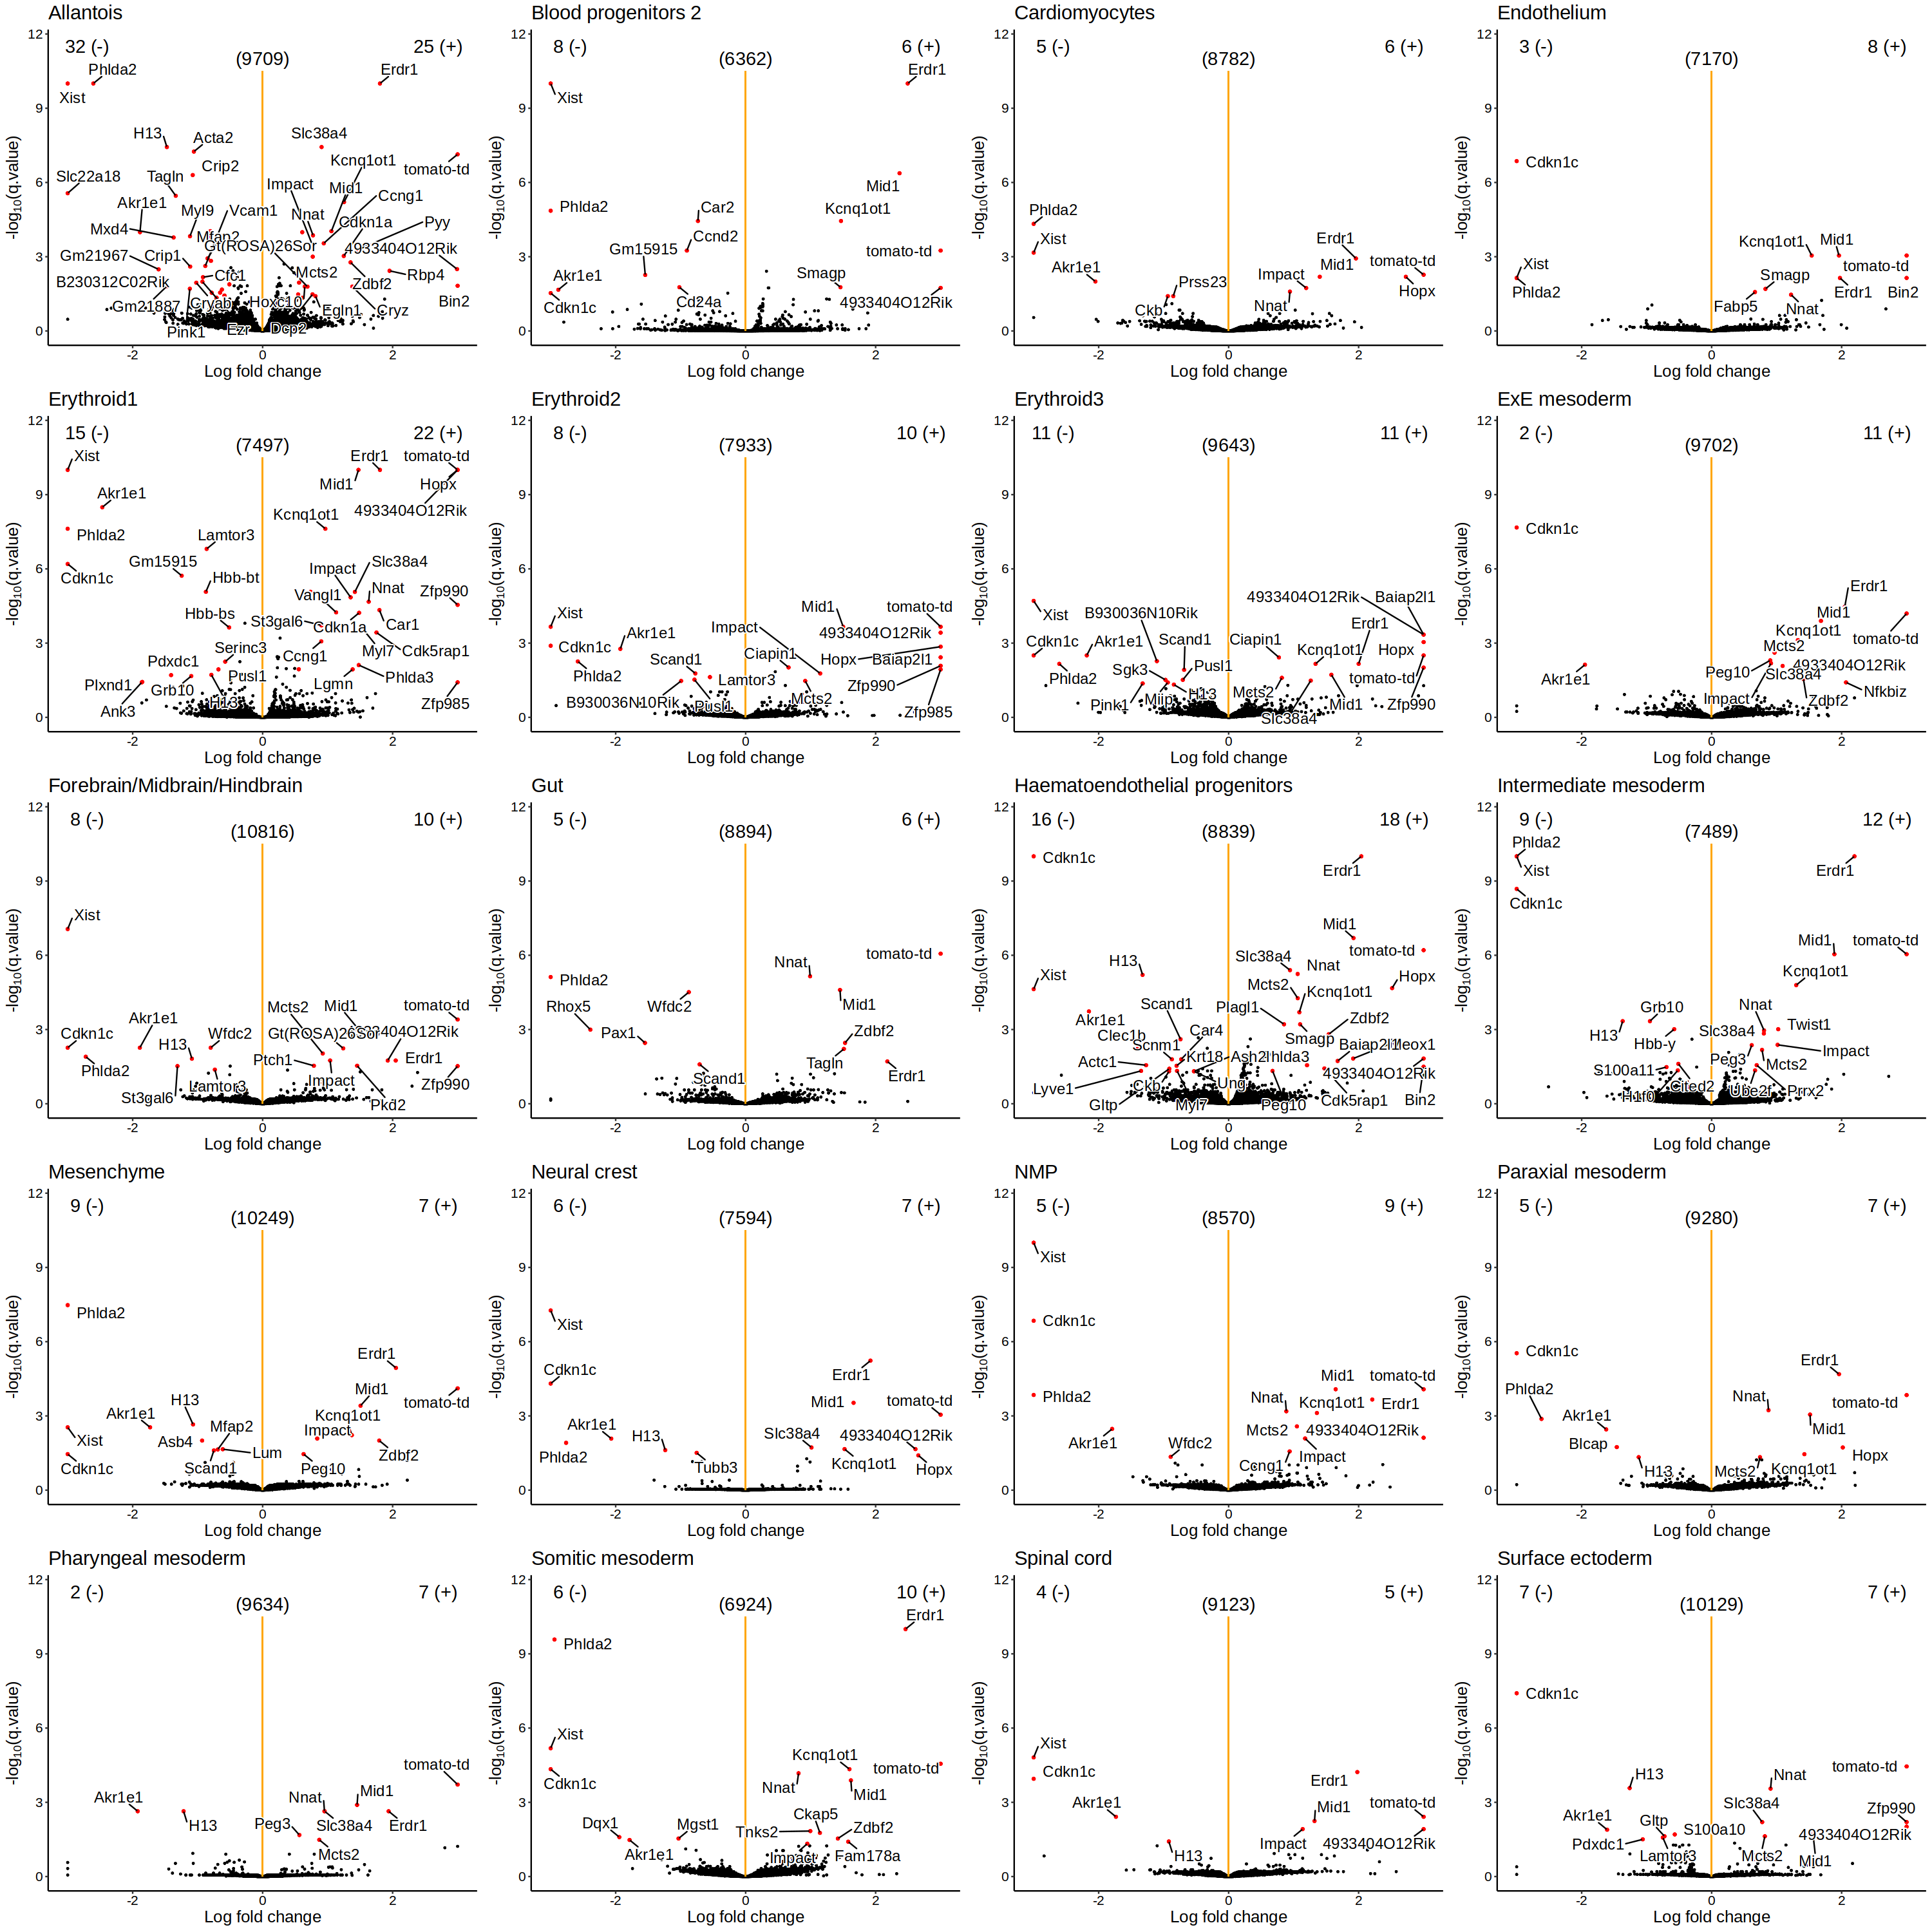

In [11]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

## DEGs across all cells

In [12]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(E85.sce, 
    id=colData(E85.sce)[,c("sample", "tomato")])

summed.filt <- summed[,summed$ncells >= 20]

In [13]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(
    summed.filt,
    label= rep('A', ncol(summed.filt)),
    design=~factor(pool) + tomato,
    coef="tomatoTRUE",
    condition=summed.filt$tomato
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


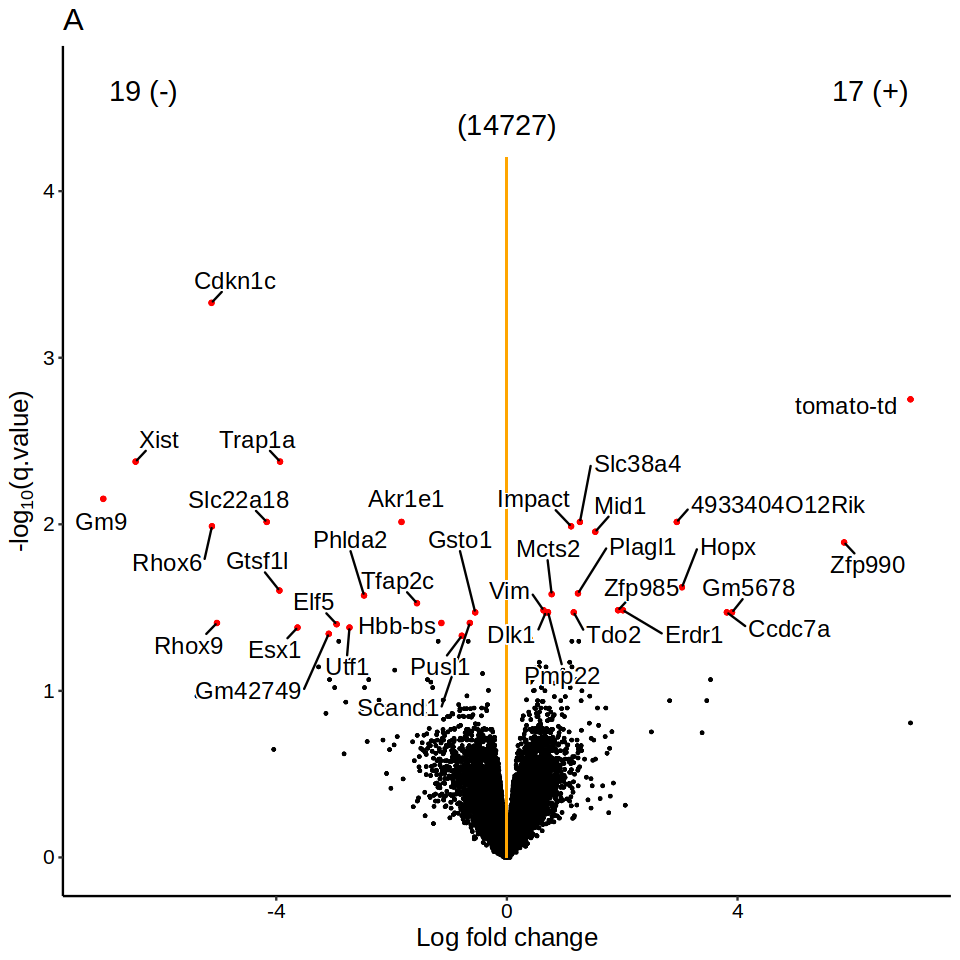

In [14]:
options(repr.plot.width=8, repr.plot.height=8)
gg_volcano_plot('A', ylim=4, xlim=7)

# E7.5 all samples

In [15]:
E75.sce = WTChimeraData(type = c("processed"), samples = c(1:4))

snapshotDate(): 2022-10-31

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for document

In [16]:
gene_metadata = fread(io$genemetadata)[, c('ens_id', 'symbol')] %>%
    rbind(., data.table(ens_id='tomato-td', symbol='tomato-td')) %>% 
    .[ens_id %in% rownames(E75.sce)] %>% 
    .[symbol!='']

E75.sce = E75.sce[rownames(E75.sce) %in% gene_metadata$ens_id]
rownames(E75.sce) = gene_metadata[match(rownames(E75.sce), ens_id), symbol]

In [17]:
E75.sce

class: SingleCellExperiment 
dim: 27995 9768 
metadata(0):
assays(1): counts
rownames(27995): Xkr4 Gm1992 ... mt-Cytb tomato-td
rowData names(2): ENSEMBL SYMBOL
colnames(9768): cell_1 cell_2 ... cell_9767 cell_9768
colData names(11): cell barcode ... doub.density sizeFactor
reducedDimNames(2): pca.corrected.E7.5 pca.corrected.E8.5
mainExpName: NULL
altExpNames(0):

In [18]:
head(colData(E75.sce))

DataFrame with 6 rows and 11 columns
              cell          barcode    sample       stage    tomato      pool
       <character>      <character> <integer> <character> <logical> <integer>
cell_1      cell_1 AAACCTGAGACCTTTG         1        E7.5      TRUE         1
cell_2      cell_2 AAACCTGAGCGCCTCA         1        E7.5      TRUE         1
cell_3      cell_3 AAACCTGAGGATCGCA         1        E7.5      TRUE         1
cell_4      cell_4 AAACCTGCACGTAAGG         1        E7.5      TRUE         1
cell_5      cell_5 AAACCTGCAGACAGGT         1        E7.5      TRUE         1
cell_6      cell_6 AAACCTGGTCTAGCCG         1        E7.5      TRUE         1
       stage.mapped        celltype.mapped closest.cell doub.density sizeFactor
        <character>            <character>  <character>    <numeric>  <numeric>
cell_1         E7.5 Haematoendothelial p..   cell_22032    0.0504199    1.16288
cell_2         E8.0             Mesenchyme  cell_116830    0.0974964    1.65059
cell_3        E7.25

In [19]:
E75.sce = E75.sce[,colData(E75.sce)$celltype.mapped != 'Doublet']

## DEGs per cell type

In [20]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(E75.sce, 
    id=colData(E75.sce)[,c("celltype.mapped", "sample", "tomato")])

summed.filt <- summed[,summed$ncells >= 20]

In [21]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(
    summed.filt,
    label=summed.filt$celltype.mapped,
    design=~factor(pool) + tomato,
    coef="tomatoTRUE",
    condition=summed.filt$tomato
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


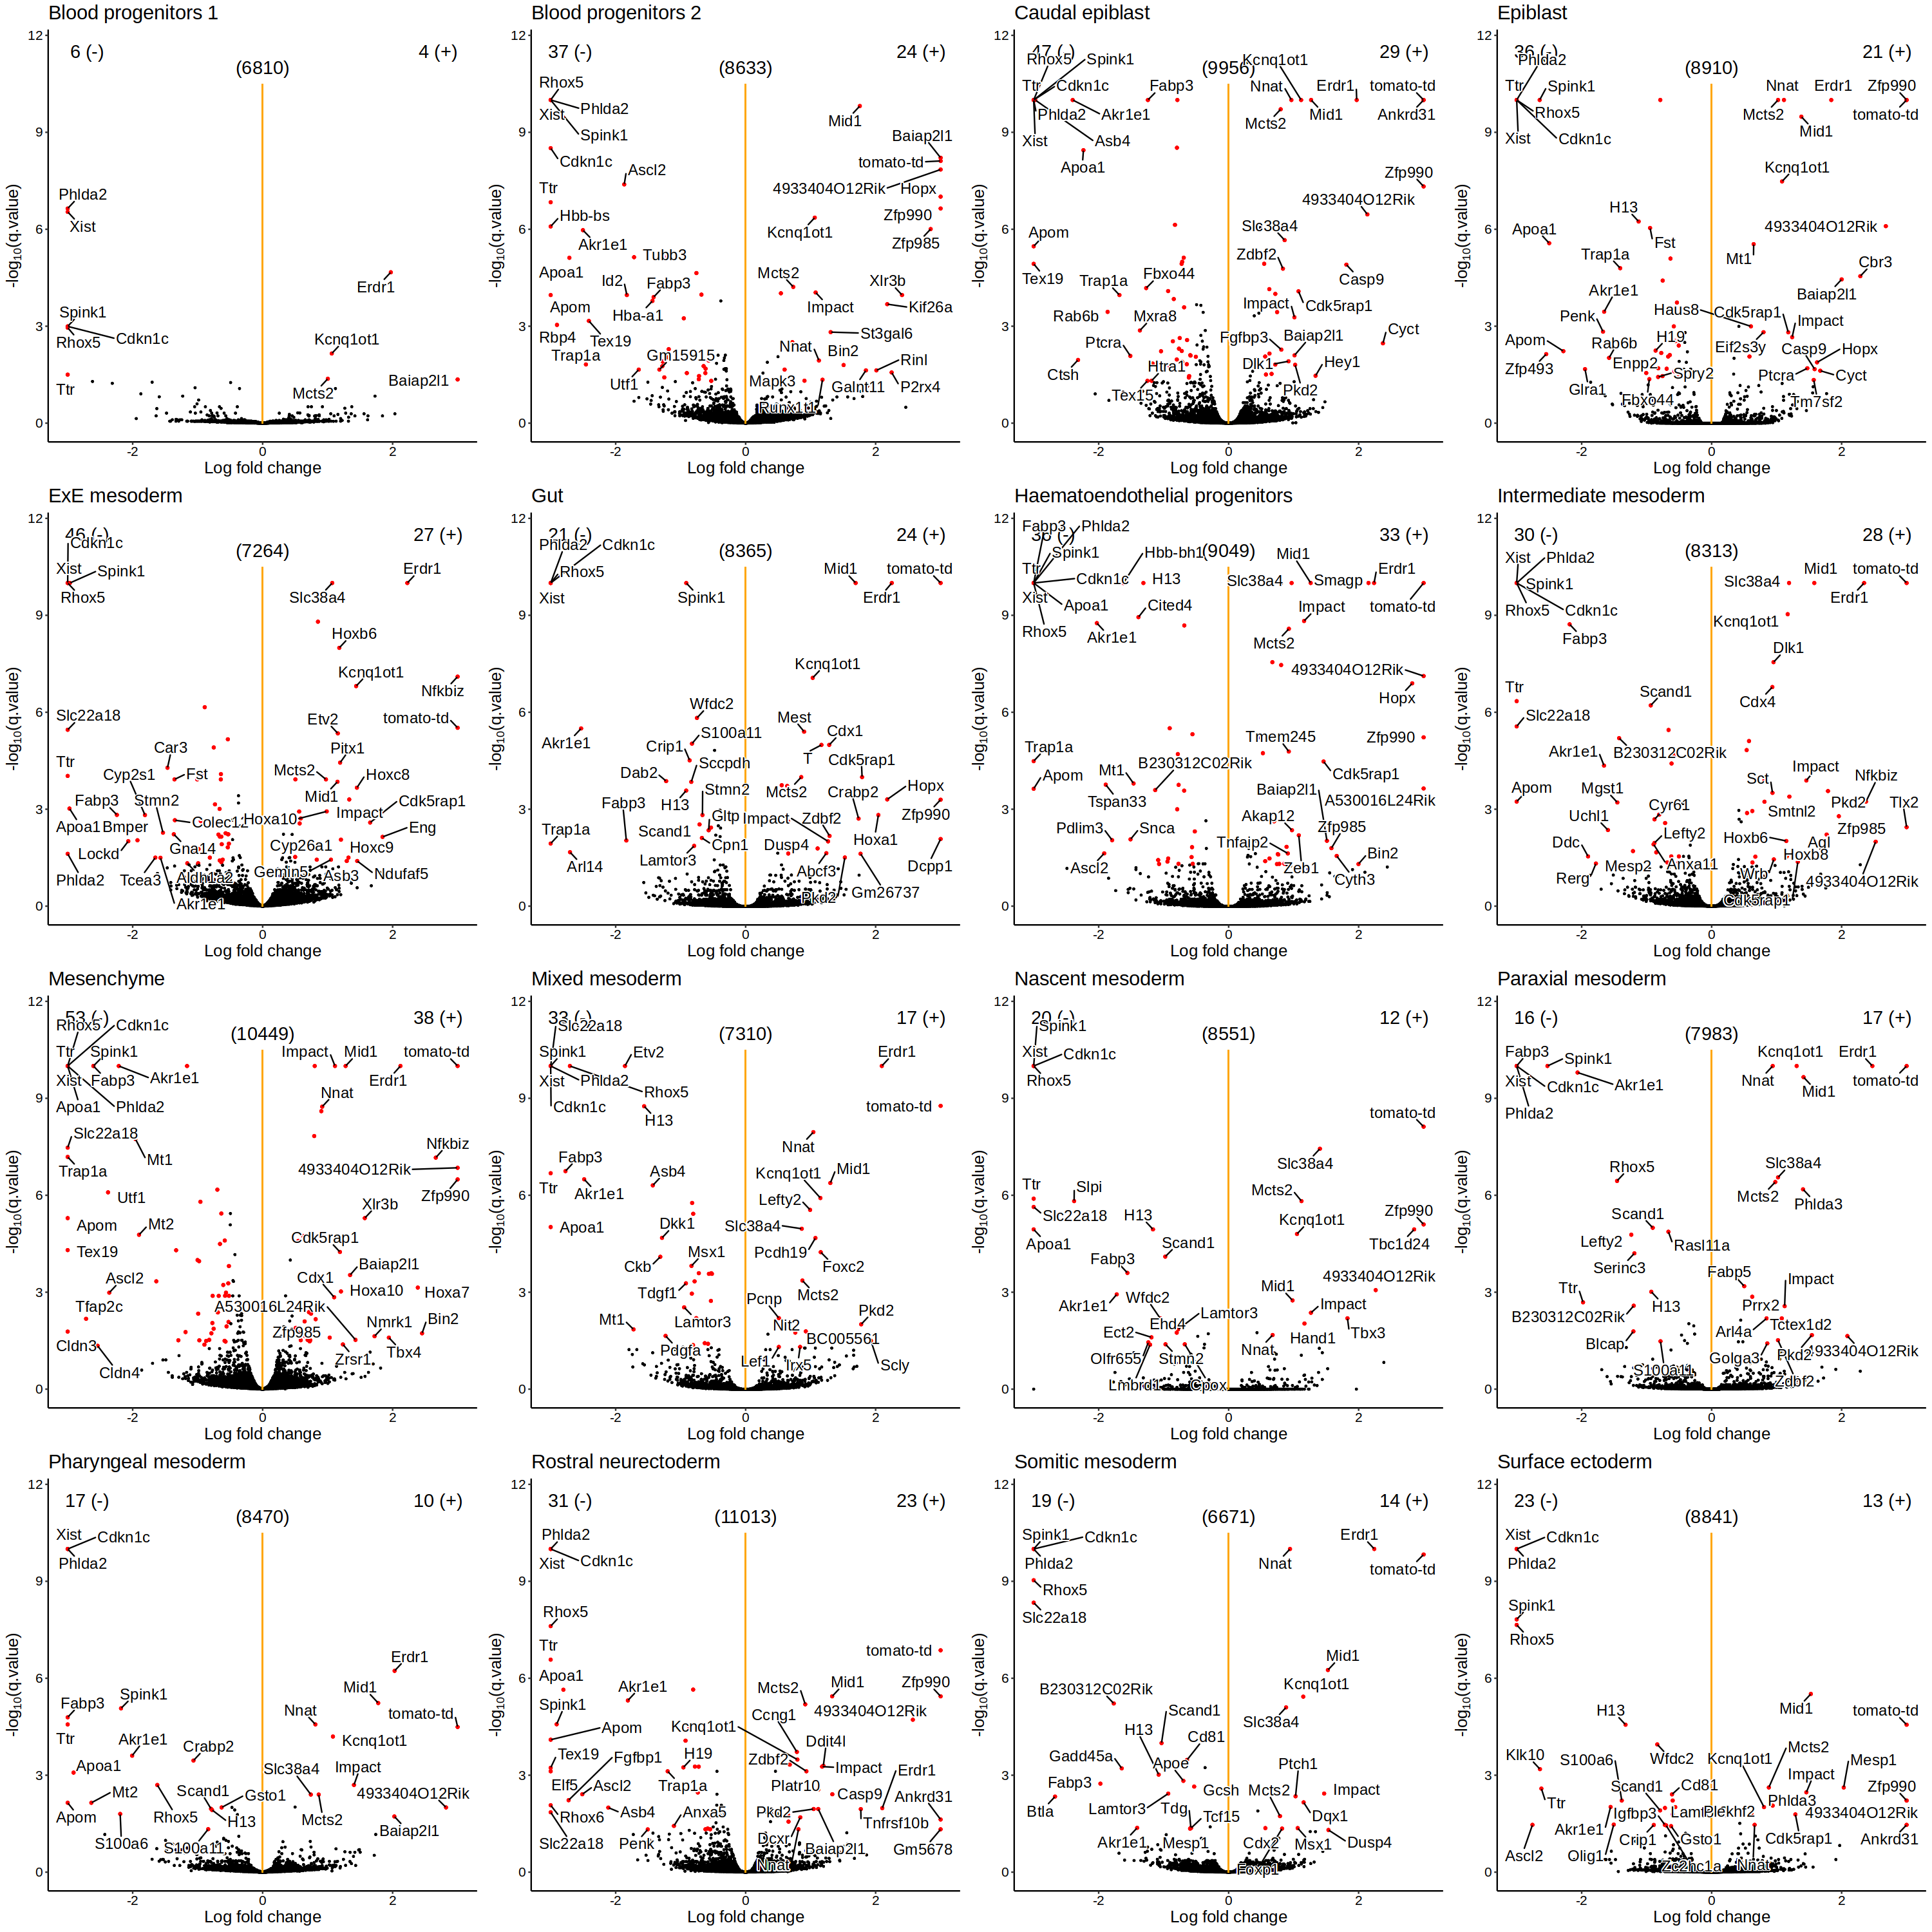

In [22]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

## DEGs across all cells

In [37]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(E75.sce, 
    id=colData(E75.sce)[,c("sample", "tomato")])

summed.filt <- summed[,summed$ncells >= 20]

In [38]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(
    summed.filt,
    label= rep('A', ncol(summed.filt)),
    design=~factor(pool) + tomato,
    coef="tomatoTRUE",
    condition=summed.filt$tomato
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


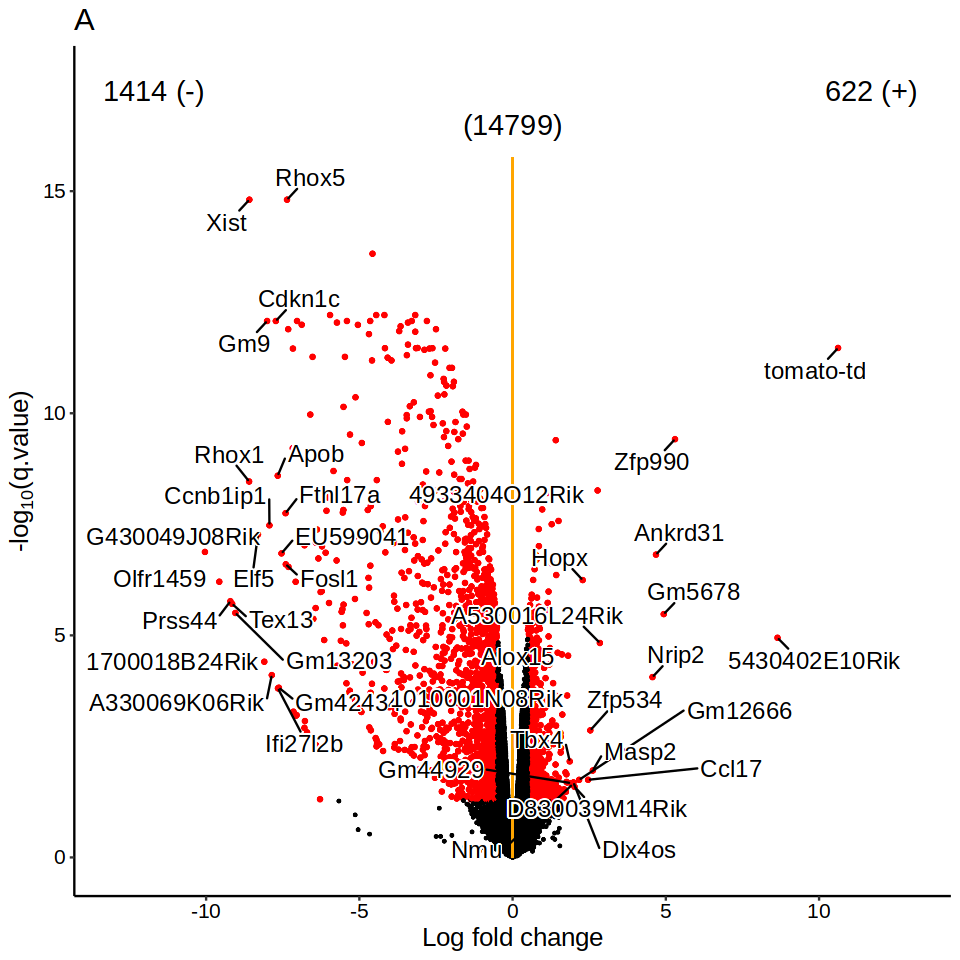

In [39]:
options(repr.plot.width=8, repr.plot.height=8)
gg_volcano_plot('A', ylim=15, xlim=13)

maybe the logFC should be set a bit higher for this one?? no idea why there are suddenly so many DEGs. Especially since it's only 2 replicat

# Quick test - E8.5 samples that weren't used by pijuan-sala

#### These 2 pools have more DEGs than the pool from sample 5 & 6. They look more typically like the data from e.g. the Eomes chimera.

In [26]:
E85.sce = WTChimeraData(type = c("processed"), samples = c(7:10))

snapshotDate(): 2022-10-31

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for documentation

loading from cache

see ?MouseGastrulationData and browseVignettes('MouseGastrulationData') for document

In [27]:
gene_metadata = fread(io$genemetadata)[, c('ens_id', 'symbol')] %>%
    rbind(., data.table(ens_id='tomato-td', symbol='tomato-td')) %>% 
    .[ens_id %in% rownames(E85.sce)] %>% 
    .[symbol!='']

E85.sce = E85.sce[rownames(E85.sce) %in% gene_metadata$ens_id]
rownames(E85.sce) = gene_metadata[match(rownames(E85.sce), ens_id), symbol]

In [28]:
E85.sce

class: SingleCellExperiment 
dim: 27995 17477 
metadata(0):
assays(1): counts
rownames(27995): Xkr4 Gm1992 ... mt-Cytb tomato-td
rowData names(2): ENSEMBL SYMBOL
colnames(17477): cell_13227 cell_13228 ... cell_30702 cell_30703
colData names(11): cell barcode ... doub.density sizeFactor
reducedDimNames(2): pca.corrected.E7.5 pca.corrected.E8.5
mainExpName: NULL
altExpNames(0):

In [29]:
head(colData(E85.sce))

DataFrame with 6 rows and 11 columns
                  cell          barcode    sample       stage    tomato
           <character>      <character> <integer> <character> <logical>
cell_13227  cell_13227 AAACCTGAGACAAGCC         7        E8.5      TRUE
cell_13228  cell_13228 AAACCTGAGCGTGAGT         7        E8.5      TRUE
cell_13229  cell_13229 AAACCTGAGGAATTAC         7        E8.5      TRUE
cell_13230  cell_13230 AAACCTGGTAAGTTCC         7        E8.5      TRUE
cell_13231  cell_13231 AAACCTGGTCGAATCT         7        E8.5      TRUE
cell_13232  cell_13232 AAACCTGTCAGGCAAG         7        E8.5      TRUE
                pool stage.mapped        celltype.mapped closest.cell
           <integer>  <character>            <character>  <character>
cell_13227         4         E8.5       Somitic mesoderm   cell_25454
cell_13228         4         E8.0                Doublet   cell_92946
cell_13229         4         E8.5 Forebrain/Midbrain/H..  cell_137089
cell_13230         4        E8.25    

In [30]:
E85.sce = E85.sce[,colData(E85.sce)$celltype.mapped != 'Doublet']

## DEGs per cell type

In [31]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(E85.sce, 
    id=colData(E85.sce)[,c("celltype.mapped", "sample", "tomato")])

summed.filt <- summed[,summed$ncells >= 20]

In [32]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(
    summed.filt,
    label=summed.filt$celltype.mapped,
    design=~factor(pool) + tomato,
    coef="tomatoTRUE",
    condition=summed.filt$tomato
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


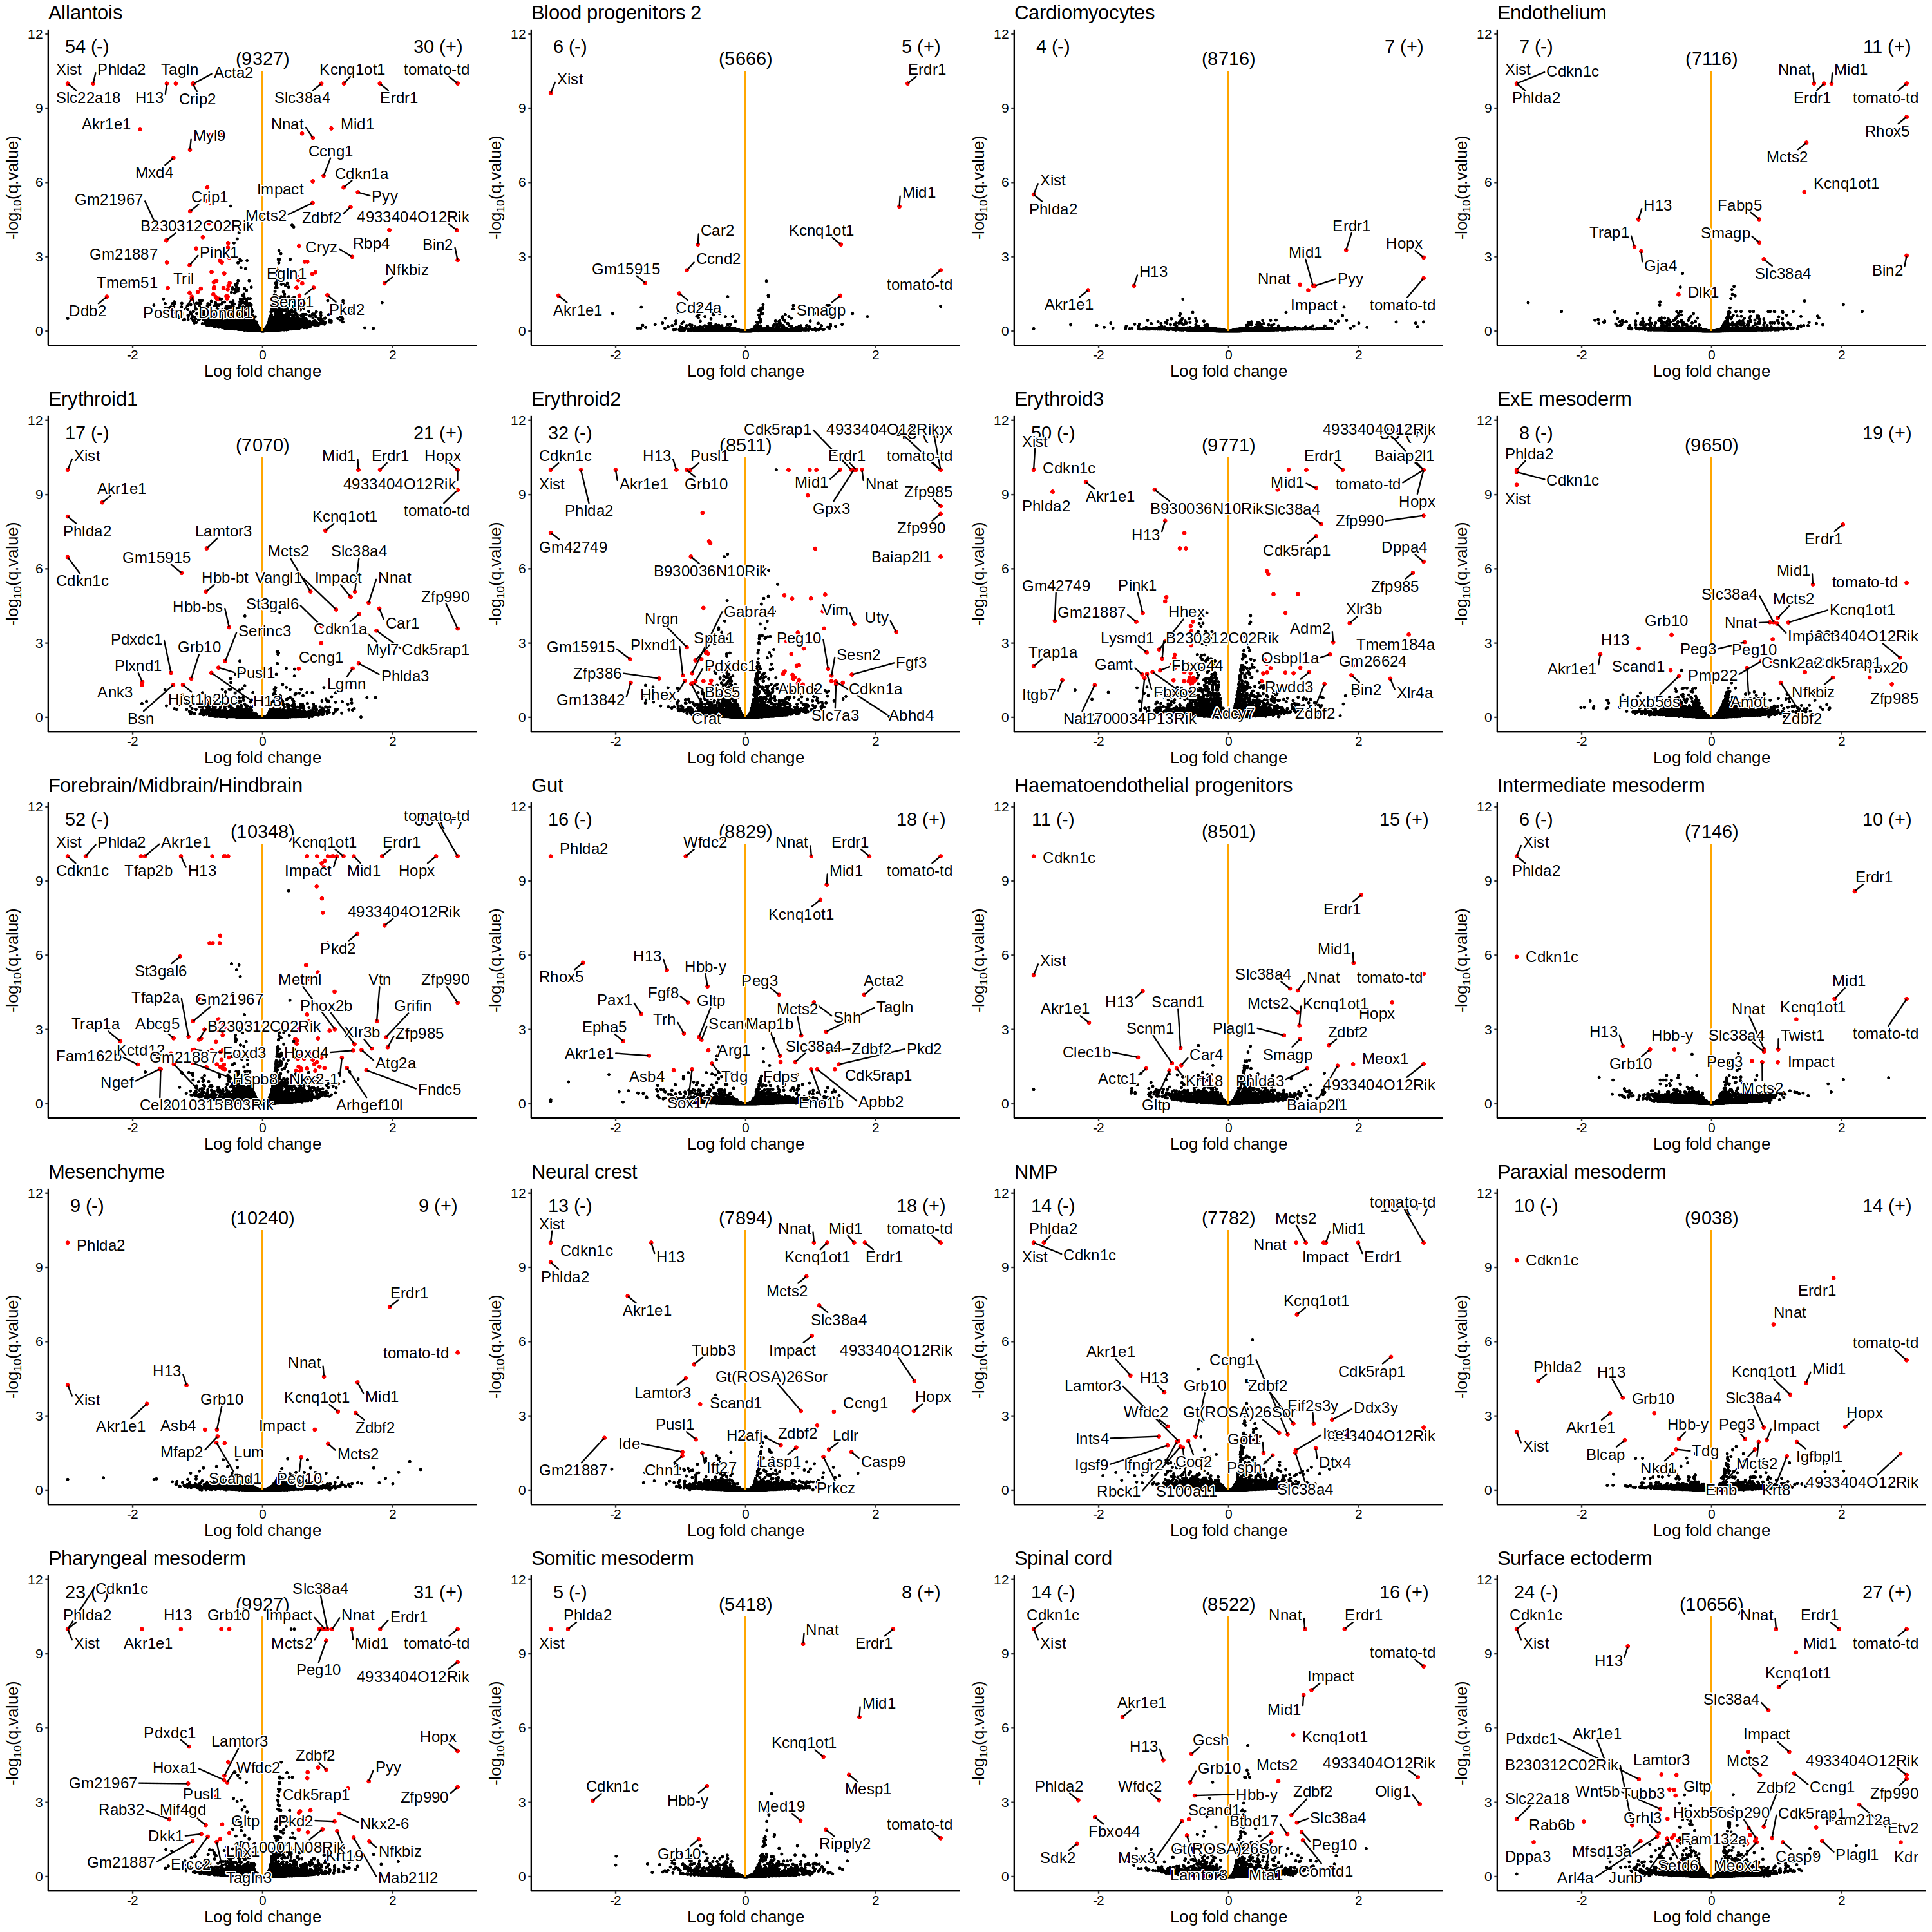

In [33]:
# Make plots
plots = lapply(unique(de.results$variable),gg_volcano_plot, ylim=10, xlim=3)
combined_plot <- cowplot::plot_grid(plotlist = plots, ncol = 4)
options(repr.plot.width=25, repr.plot.height=25)
combined_plot

## DEGs across all cells

In [34]:
# Pseudobulk by sample and variable
summed <- aggregateAcrossCells(E85.sce, 
    id=colData(E85.sce)[,c("sample", "tomato")])

summed.filt <- summed[,summed$ncells >= 20]

In [35]:
# specific genes
# Genes are tested to be significantly different from the average LFC of all cell-types
de.results <- pseudoBulkDGE(
    summed.filt,
    label= rep('A', ncol(summed.filt)),
    design=~factor(pool) + tomato,
    coef="tomatoTRUE",
    condition=summed.filt$tomato
    ) %>% unlist() %>% 
        as.data.table(keep.rownames=T) %>%
        .[,`:=`(gene=str_split(rn, '\\.') %>% map_chr(2), # extract gene names
                variable=str_split(rn, '\\.') %>% map_chr(1), # extract cell type
                rn=NULL, 
                sig=ifelse(abs(logFC)>=0.5 & FDR<=0.05, TRUE, FALSE))] %>%  # significance
        .[!is.na(logFC),] %>%
        setnames('FDR', 'padj_fdr')

Warning message in .local(x, row.names, optional, ...):
“Arguments in '...' ignored”


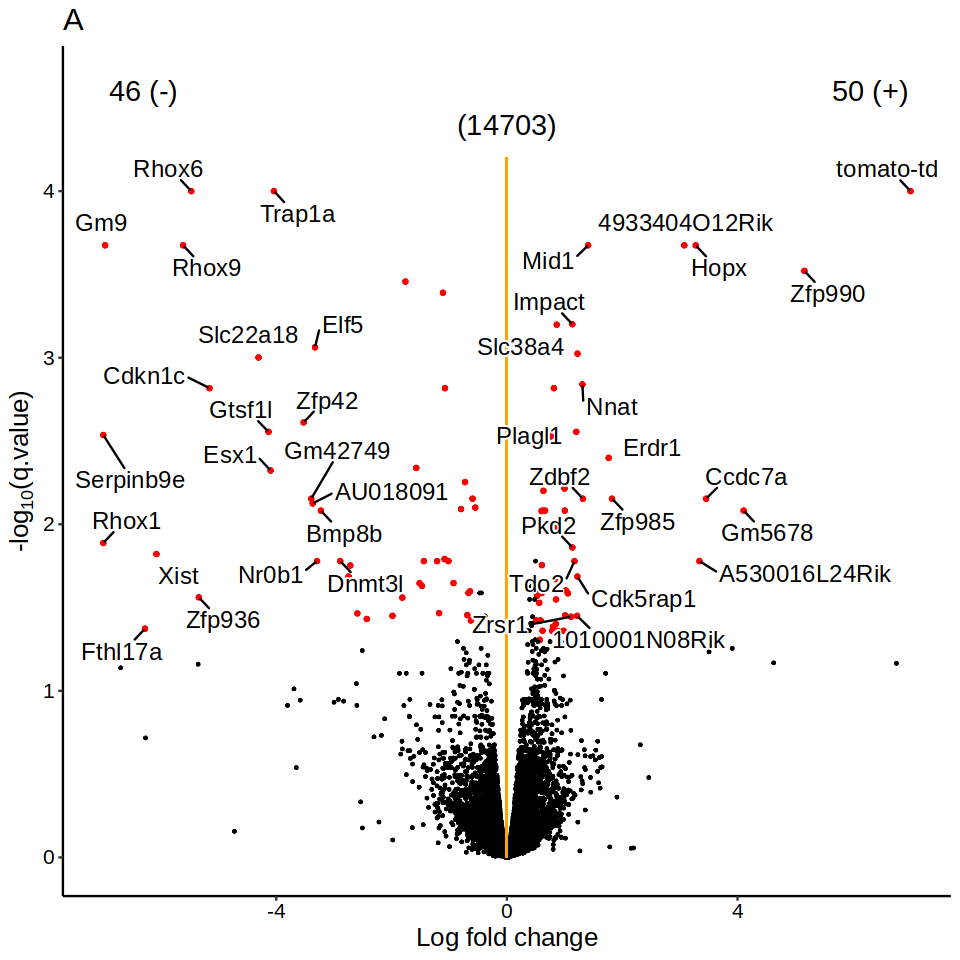

In [36]:
options(repr.plot.width=8, repr.plot.height=8)
gg_volcano_plot('A', ylim=4, xlim=7)